## Assignment 2 Part 3
### Import Modules

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import statsmodels.api as sm

In [3]:
from sklearn.linear_model import LinearRegression

In [74]:
from statsmodels.stats.stattools import durbin_watson

In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [138]:
pd.set_option('display.max_colwidth', None)

In [68]:
# Function to look at simple linear regression
def cesar(data, df_num, xlist):
    df_num = df_num
    
    df = pd.read_csv(data)
    df.head()

    # Keep x features and y features
    x = df[xlist]
    y = df[["y"]]

    # Initialize the LinearRegression object
    model = LinearRegression()

    # Run the model with our features
    model.fit(x, y)

    # Predicted
    y_pred = model.predict(x)
    df["y_pred"] = y_pred

    # Residuals
    residuals = df["y"] - df["y_pred"]
    df["residuals"] = residuals

    # Intercept
    intercept = round(model.intercept_[0], 3)
    # Features
    coef = round(model.coef_[0][0], 3)

    # Scatterplot for Linearity
    sns.relplot(data=df, x="X", y="y")
    plt.title(f"Scatterplot of Dataset {df_num}")
    plt.savefig(f"Scatterplot of Dataset {df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Plot residuals vs. fitted values
    plt.scatter(y_pred, df["residuals"], alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs. Fitted Values')
    plt.savefig(f"Residuals vs. Fitted Values for Dataset {df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Durbin Watson for Independence
    dubs = round(durbin_watson(residuals), 3)

    # Normality of Residuals
    sns.histplot(residuals)
    plt.title(f"Histogram_Dataset {df_num}")
    plt.savefig(f"Histogram_Dataset {df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Intercept: {intercept}")
    print(f"Coefficient X: {coef}")
    print(f"Durbin-Watson: {dubs}")

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


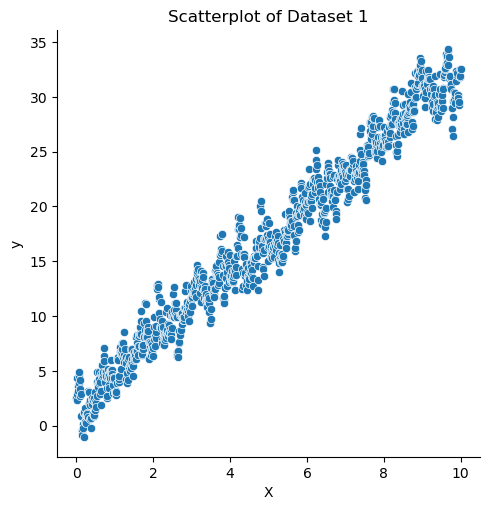

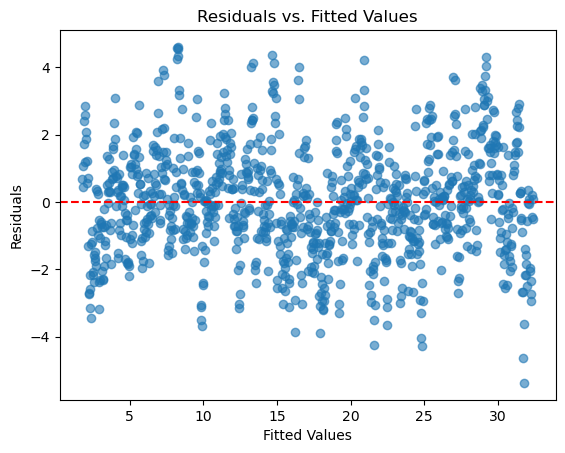

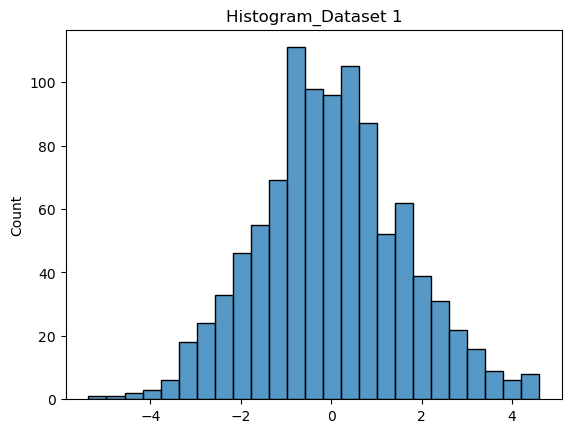

Intercept: 1.798
Coefficient X: 3.059
Durbin-Watson: 0.41


In [62]:
cesar("APMM8-assignment2-dataset10.csv", 1, ["X"])

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


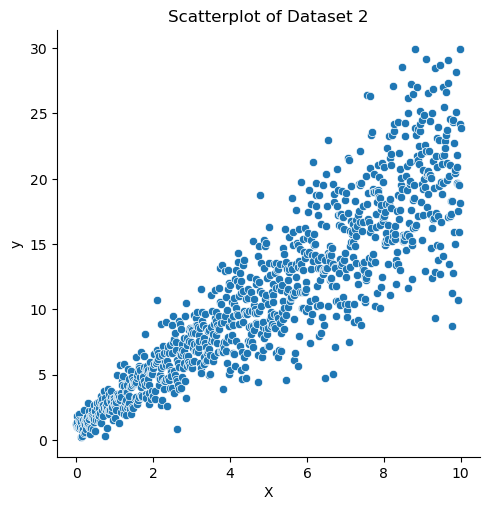

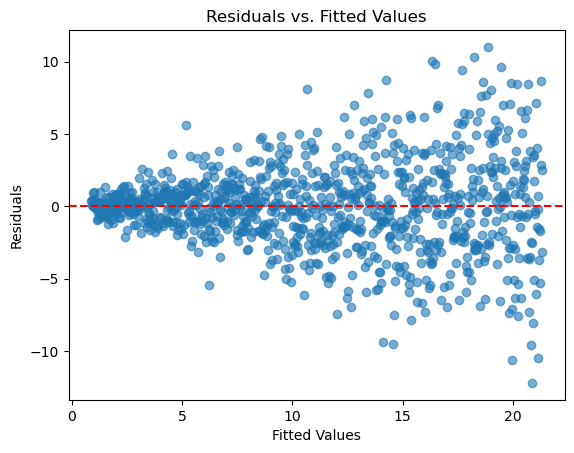

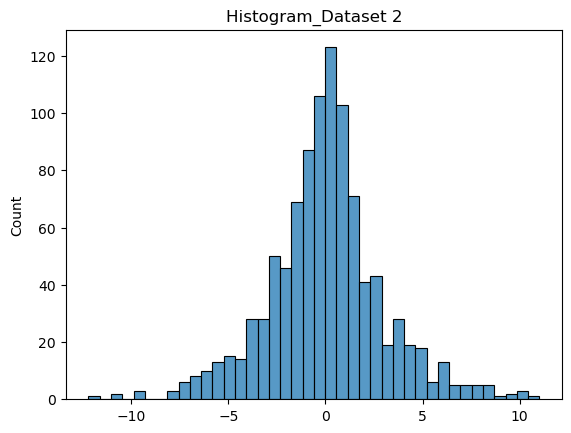

Intercept: 0.869
Coefficient X: 2.046
Durbin-Watson: 1.98


In [63]:
cesar("APMM8-assignment2-dataset11.csv", 2, ["X"])

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


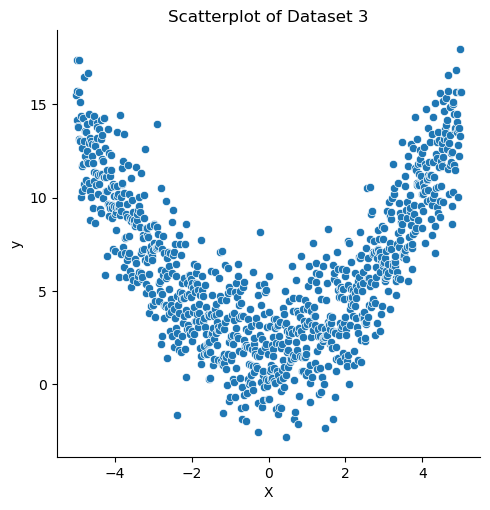

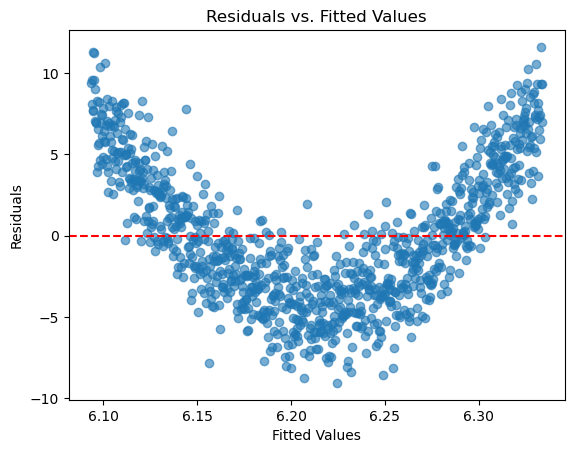

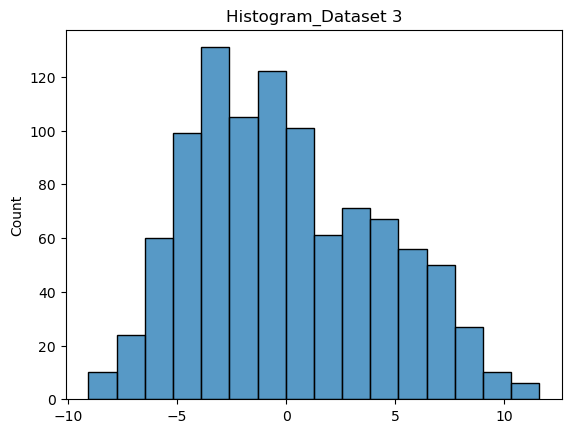

Intercept: 6.214
Coefficient X: 0.024
Durbin-Watson: 0.431


In [64]:
cesar("APMM8-assignment2-dataset13.csv", 3, ["X"])

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


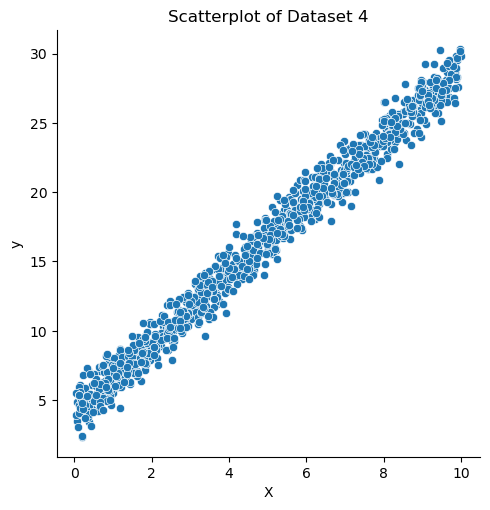

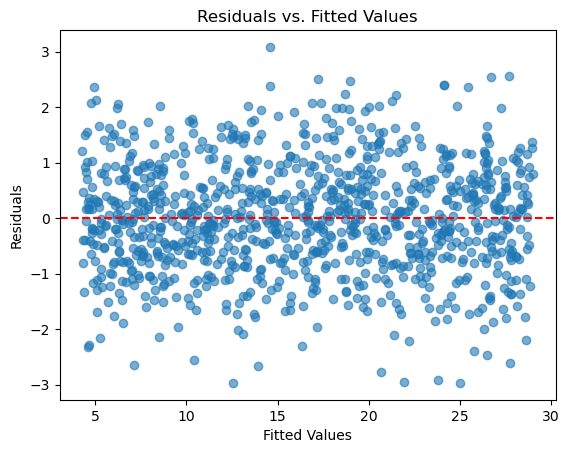

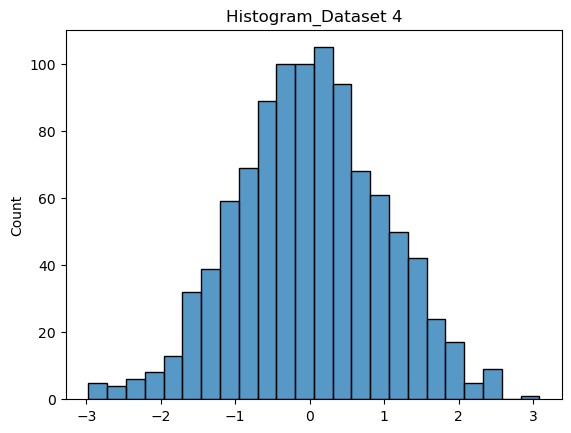

Intercept: 4.175
Coefficient X: 2.485
Durbin-Watson: 2.002


In [66]:
cesar("APMM8-assignment2-dataset14.csv", 4, ["X"])

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


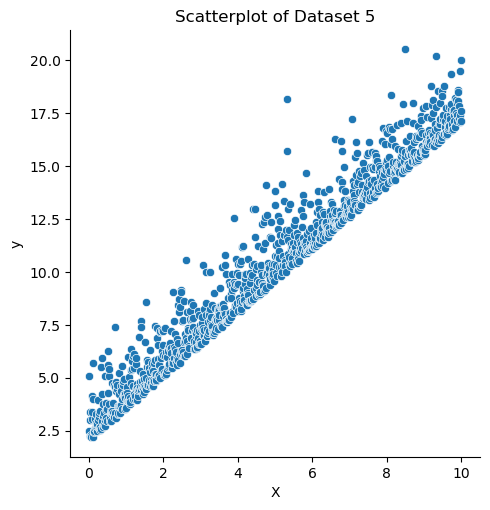

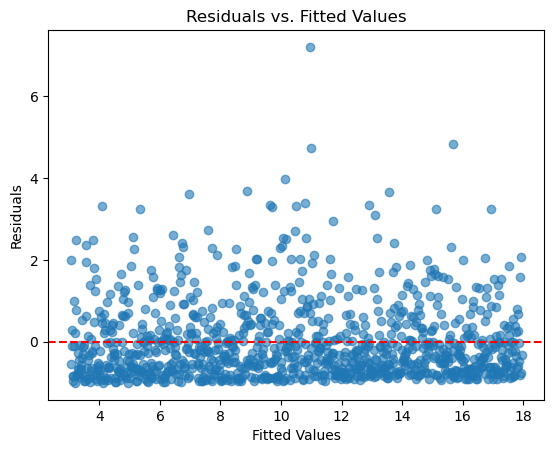

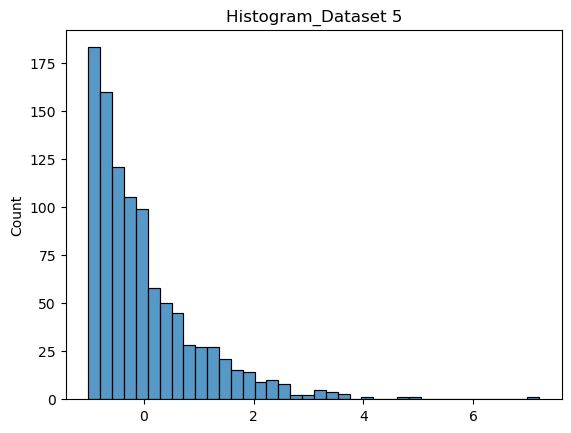

Intercept: 3.05
Coefficient X: 1.49
Durbin-Watson: 1.869


In [67]:
cesar("APMM8-assignment2-dataset15.csv", 5, ["X"])

In [99]:
# Function to look at multiple linear regression
def cesar(data, df_num):
    df_num = df_num
    
    df = pd.read_csv(data)
    df.head()

    xlist = df.drop(columns=["y"]).columns.to_list()
    
    # Keep x features and y features
    x = df[xlist]
    y = df[["y"]]

    # Initialize the LinearRegression object
    model = LinearRegression()

    # Run the model with our features
    model.fit(x, y)

    # Predicted
    y_pred = model.predict(x)
    df["y_pred"] = y_pred

    # Residuals
    residuals = df["y"] - df["y_pred"]
    df["residuals"] = residuals

    # Intercept and coefficients
    intercept = round(model.intercept_[0], 3)
    coefs = [round(c, 3) for c in model.coef_[0]]
    
    # Linearity plots for each predictor
    for xi in xlist:
        sns.scatterplot(data=df, x=xi, y="y")
        plt.title(f"Scatterplot of {xi} vs y (Dataset {df_num})")
        plt.xlabel(xi)
        plt.ylabel("y")
        plt.savefig(f"Scatterplot_{xi}_Dataset_{df_num}.png", dpi=300, bbox_inches='tight')
        plt.show()

    # Residuals vs Fitted Values plot
    plt.scatter(df["y_pred"], df["residuals"], alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Fitted Values (Dataset {df_num})')
    plt.savefig(f"Residuals_vs_Fitted_Dataset_{df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Durbin-Watson test for independence
    dubs = round(durbin_watson(df["residuals"]), 3)

    # Histogram of residuals
    sns.histplot(df["residuals"], kde=True)
    plt.title(f"Histogram of Residuals (Dataset {df_num})")
    plt.savefig(f"Histogram_Residuals_Dataset_{df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Multicollinearity (VIF)
    x_add = sm.add_constant(x)  # Adds intercept term

    vif_data = pd.DataFrame()
    vif_data["Feature"] = x_add.columns
    vif_data["VIF"] = [variance_inflation_factor(x_add.values, i)
                       for i in range(x_add.shape[1])]

    # Correlation matrix heatmap
    corr_matrix = x.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation Heatmap of Predictors (Dataset {df_num})")
    plt.savefig(f"Correlation_Heatmap_Dataset_{df_num}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Print results
    print(f"Intercept: {intercept}")
    for i, coef in enumerate(coefs):
        print(f"Coefficient for {xlist[i]}: {coef}")
    print(f"Durbin-Watson: {dubs}")
    print("\nVariance Inflation Factors (VIF):")
    print(vif_data)

    # Store all important outputs in a dictionary
    results = {
        "data": data,
        "dataset": df_num,
        "intercept": intercept,
        "coefficients": dict(zip(xlist, coefs)),
        "durbin_watson": dubs,
        "vif": vif_data,
        "correlation_matrix": corr_matrix,
        "residuals": df["residuals"],
        "predictions": df["y_pred"]
    }

    return results

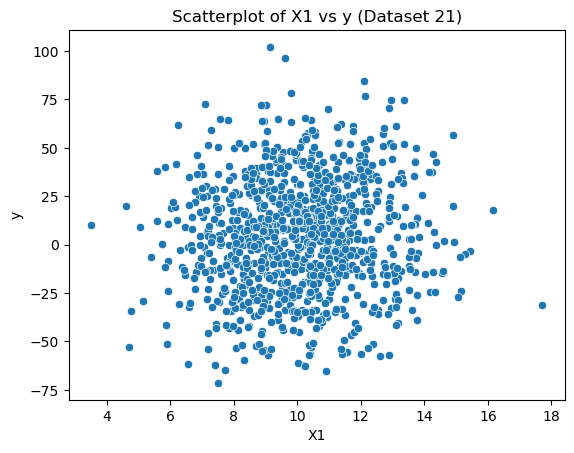

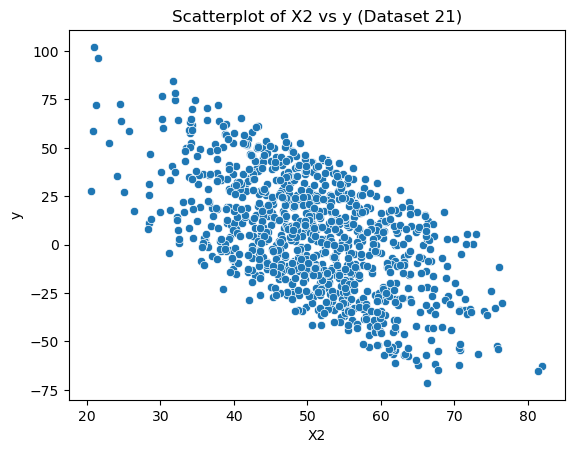

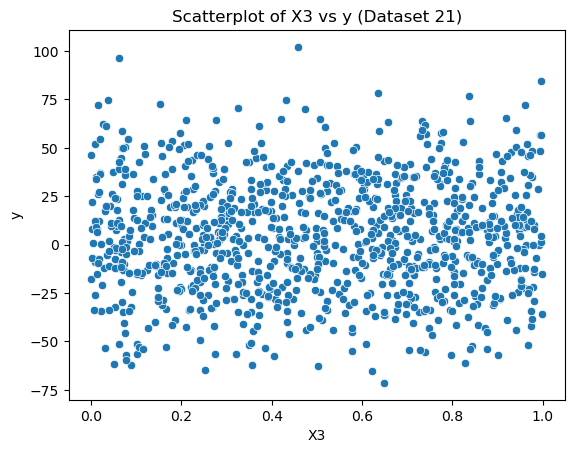

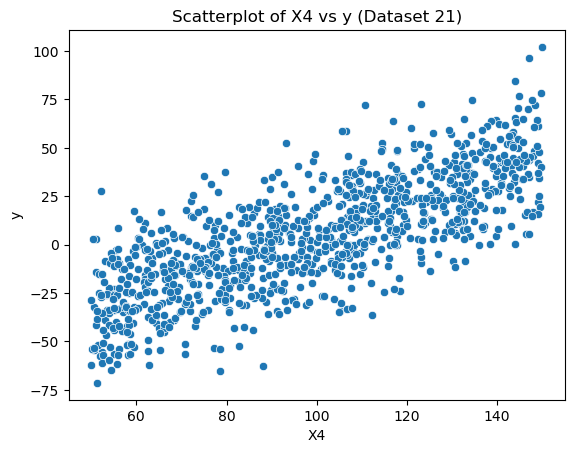

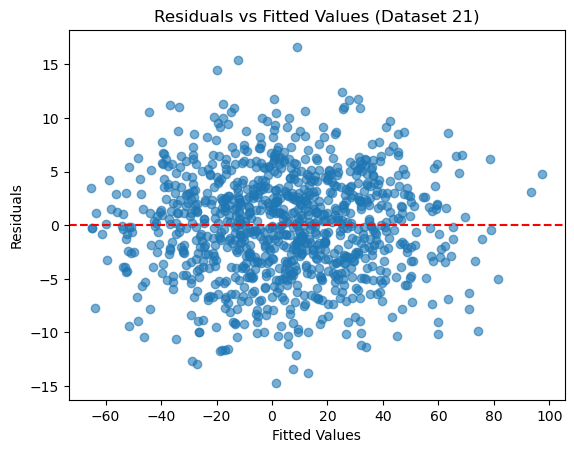

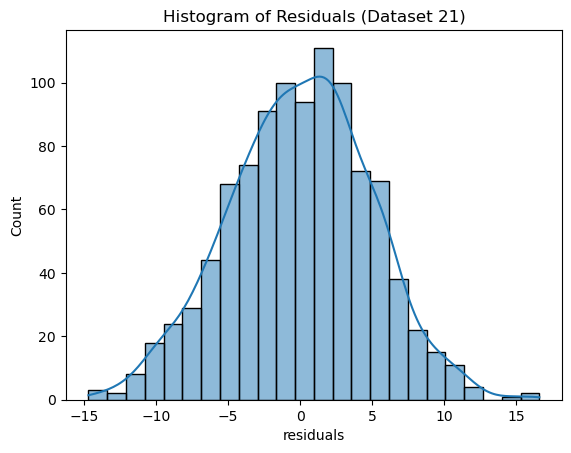

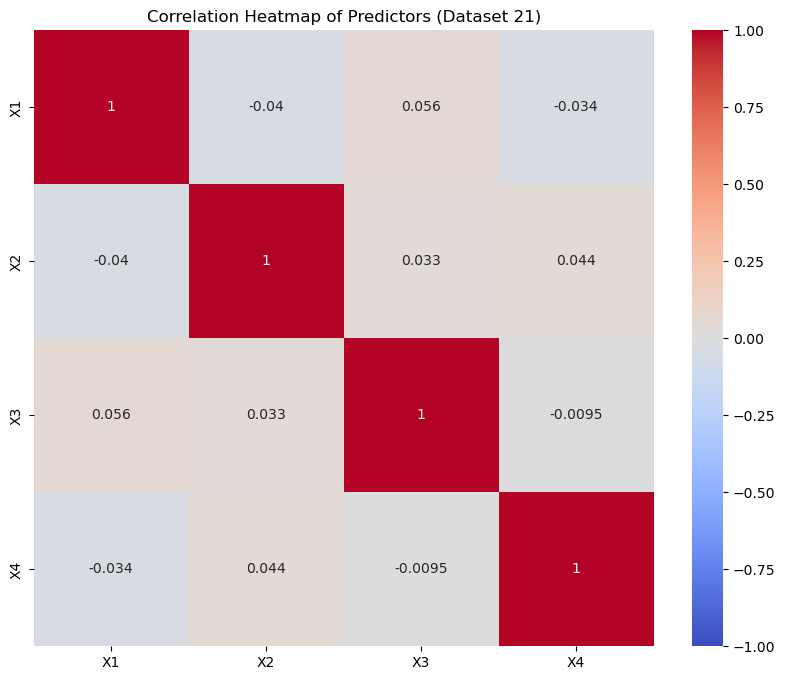

Intercept: 2.82
Coefficient for X1: 1.135
Coefficient for X2: -1.785
Coefficient for X3: 3.249
Coefficient for X4: 0.802
Durbin-Watson: 2.011

Variance Inflation Factors (VIF):
  Feature        VIF
0   const  68.759277
1      X1   1.005927
2      X2   1.004735
3      X3   1.004440
4      X4   1.003075


{'data': 'APMM8-assignment2-dataset21.csv',
 'dataset': 21,
 'intercept': 2.82,
 'coefficients': {'X1': 1.135, 'X2': -1.785, 'X3': 3.249, 'X4': 0.802},
 'durbin_watson': 2.011,
 'vif':   Feature        VIF
 0   const  68.759277
 1      X1   1.005927
 2      X2   1.004735
 3      X3   1.004440
 4      X4   1.003075,
 'correlation_matrix':           X1        X2        X3        X4
 X1  1.000000 -0.040400  0.055580 -0.034252
 X2 -0.040400  1.000000  0.033051  0.043879
 X3  0.055580  0.033051  1.000000 -0.009530
 X4 -0.034252  0.043879 -0.009530  1.000000,
 'residuals': 0       5.451692
 1       2.822115
 2      11.727332
 3      -7.041149
 4       6.674103
          ...    
 995     5.978303
 996     5.930437
 997     4.798076
 998    -2.289999
 999    -4.952180
 Name: residuals, Length: 1000, dtype: float64,
 'predictions': 0     -33.284092
 1      -6.440043
 2      30.971641
 3      -8.640067
 4       1.180943
          ...    
 995   -30.916751
 996     4.452633
 997    47.777256
 998

In [100]:
cesar("APMM8-assignment2-dataset21.csv", 21)

In [83]:
# df = pd.read_csv("APMM8-assignment2-dataset22.csv")
# df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   y       1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


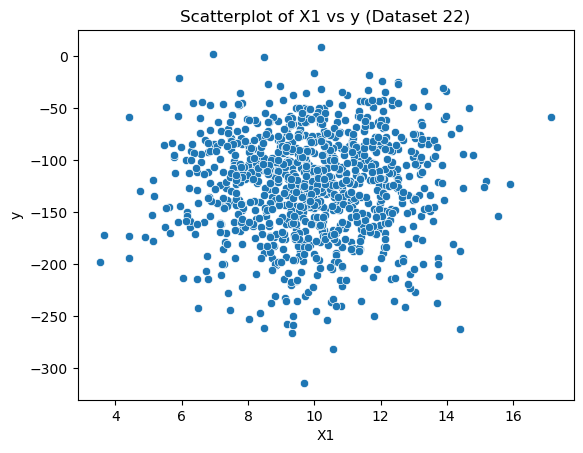

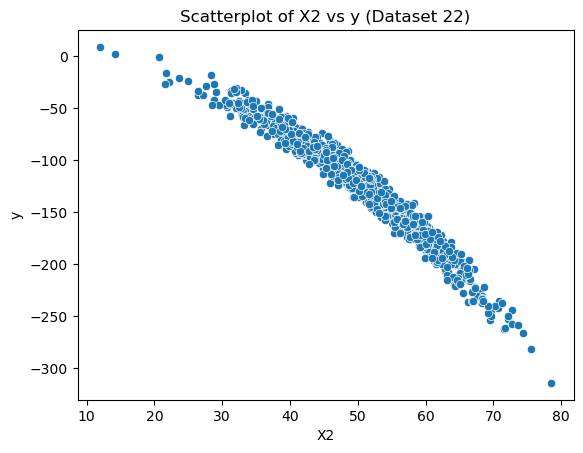

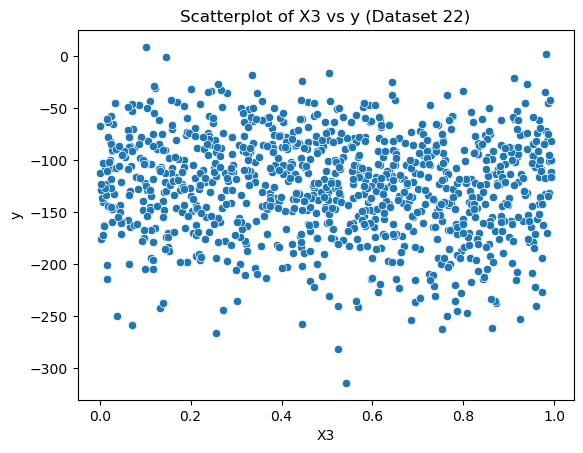

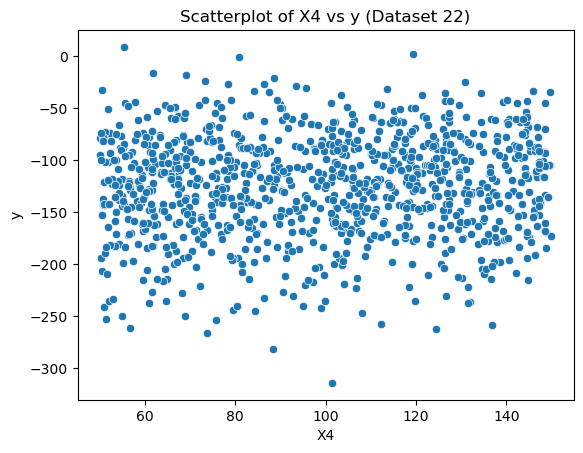

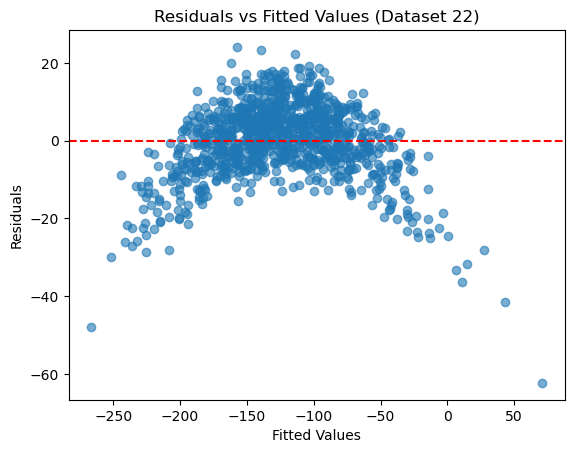

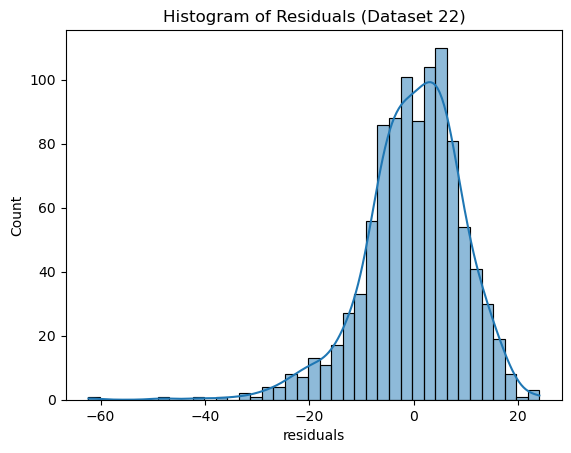

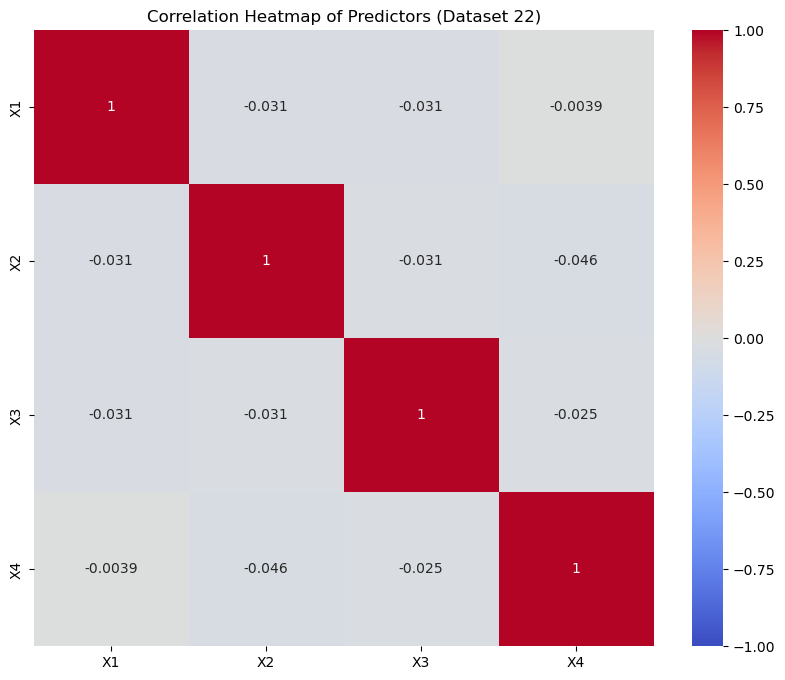

Intercept: 130.433
Coefficient for X1: 0.075
Coefficient for X2: -4.95
Coefficient for X3: -20.356
Coefficient for X4: 0.019
Durbin-Watson: 2.133

Variance Inflation Factors (VIF):
  Feature        VIF
0   const  72.776539
1      X1   1.002065
2      X2   1.004274
3      X3   1.002735
4      X4   1.002910


In [84]:
cesar("APMM8-assignment2-dataset22.csv", 22, ["X1", "X2", "X3", "X4"])

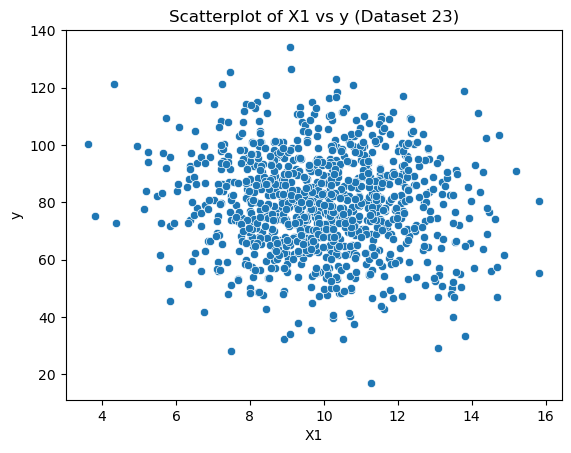

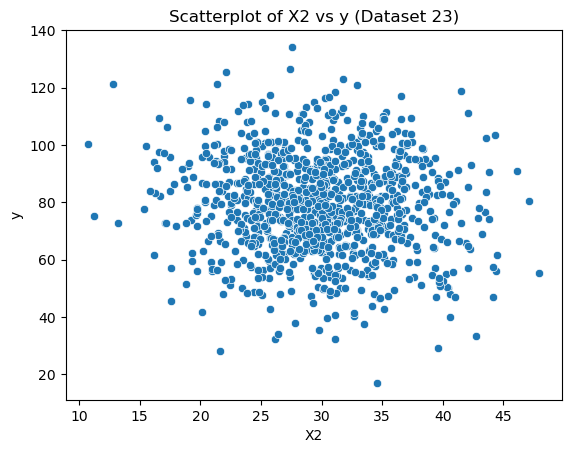

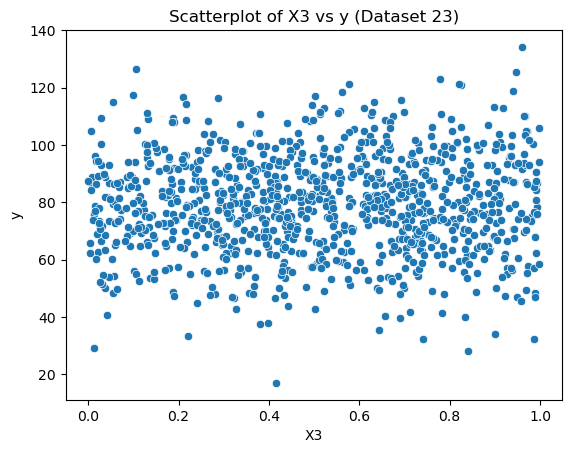

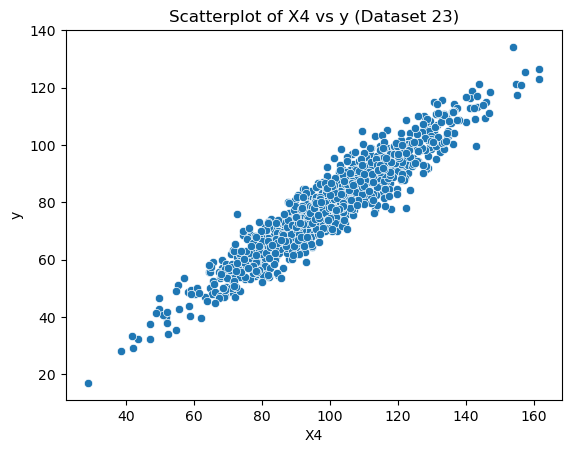

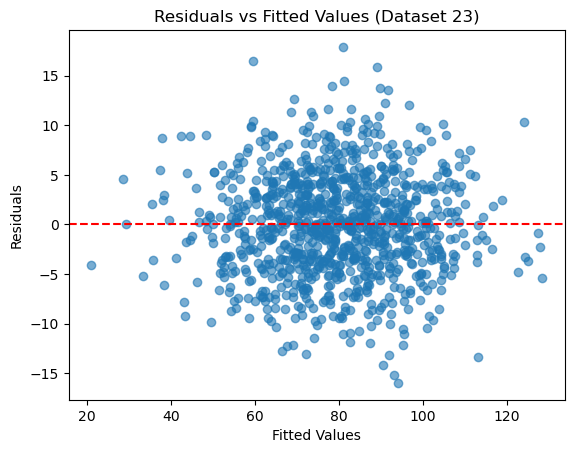

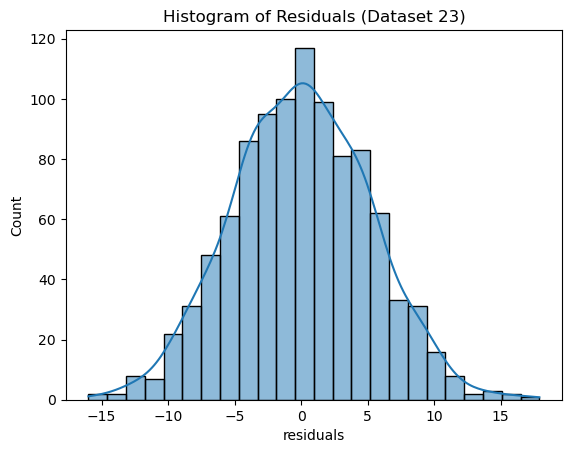

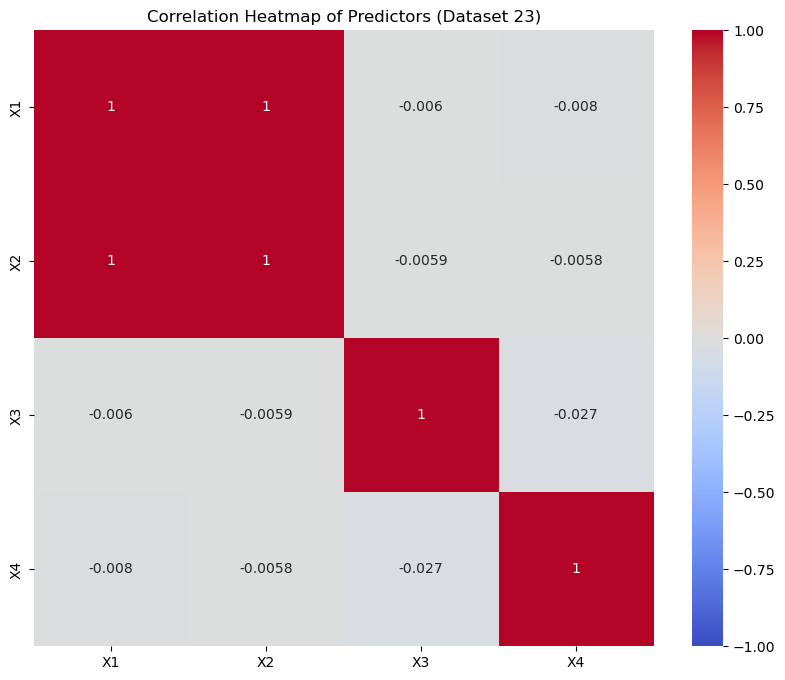

Intercept: 4.034
Coefficient for X1: 0.996
Coefficient for X2: -0.54
Coefficient for X3: 3.206
Coefficient for X4: 0.796
Durbin-Watson: 1.982

Variance Inflation Factors (VIF):
  Feature         VIF
0   const   56.648174
1      X1  128.794329
2      X2  128.790165
3      X3    1.000759
4      X4    1.001425


{'data': 'APMM8-assignment2-dataset23.csv',
 'dataset': 23,
 'intercept': 4.034,
 'coefficients': {'X1': 0.996, 'X2': -0.54, 'X3': 3.206, 'X4': 0.796},
 'durbin_watson': 1.982,
 'vif':   Feature         VIF
 0   const   56.648174
 1      X1  128.794329
 2      X2  128.790165
 3      X3    1.000759
 4      X4    1.001425,
 'correlation_matrix':           X1        X2        X3        X4
 X1  1.000000  0.996108 -0.005984 -0.008017
 X2  0.996108  1.000000 -0.005943 -0.005762
 X3 -0.005984 -0.005943  1.000000 -0.026823
 X4 -0.008017 -0.005762 -0.026823  1.000000,
 'residuals': 0      6.388117
 1     -4.693613
 2     -9.222198
 3      4.660568
 4     -5.181883
          ...   
 995   -2.233286
 996    2.165384
 997    1.596109
 998   -1.811744
 999   -0.663582
 Name: residuals, Length: 1000, dtype: float64,
 'predictions': 0       80.621192
 1       86.884316
 2       78.547827
 3       84.523677
 4       74.259247
           ...    
 995    127.832573
 996     78.076449
 997     71.156405


In [90]:
cesar("APMM8-assignment2-dataset23.csv", 23, ["X1", "X2", "X3", "X4"])

In [103]:
featlist = [10, 11, 13, 14, 15, 21, 22, 23, 24, 25]

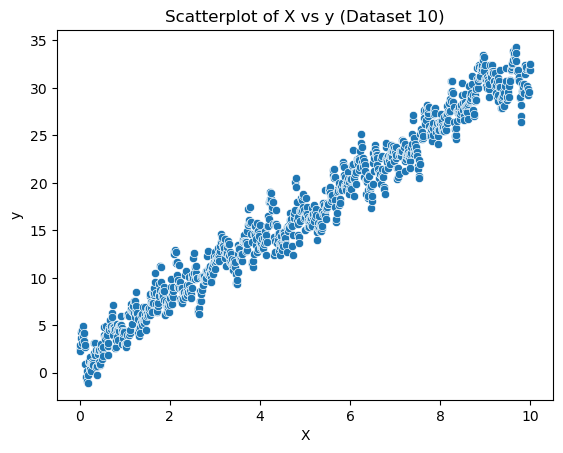

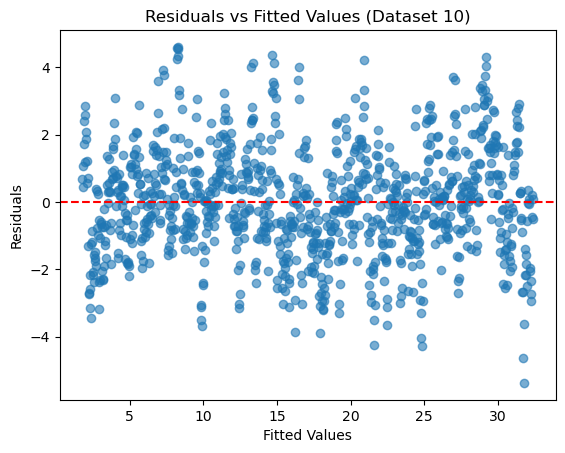

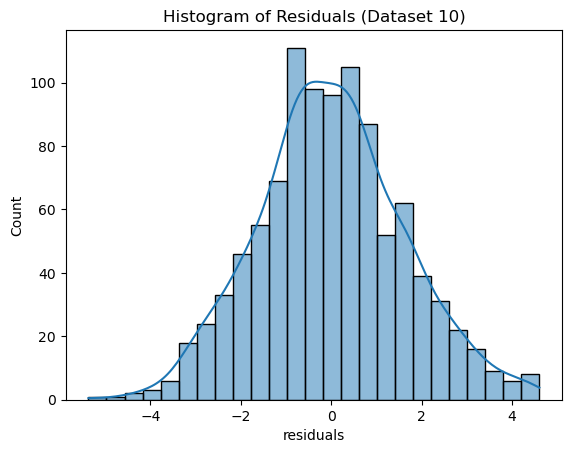

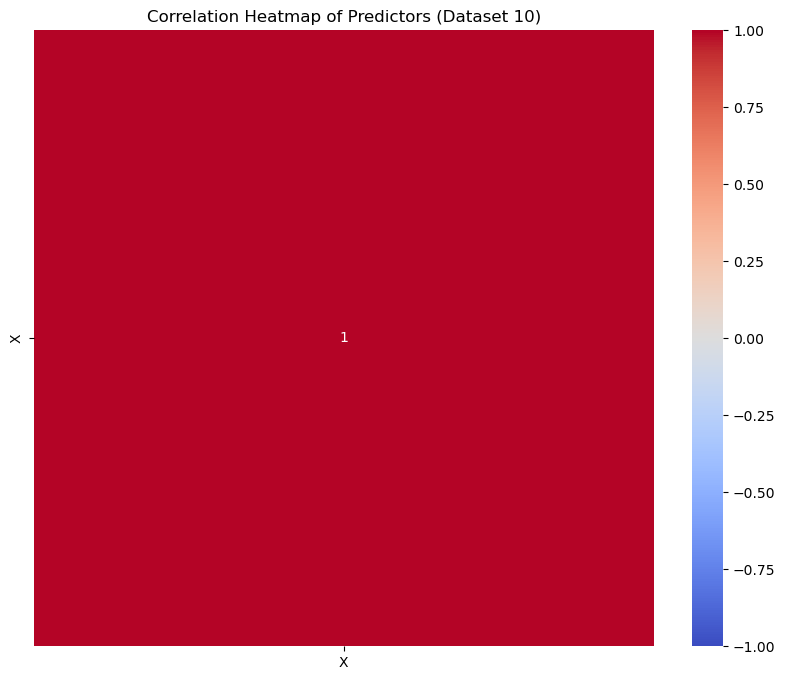

Intercept: 1.798
Coefficient for X: 3.059
Durbin-Watson: 0.41

Variance Inflation Factors (VIF):
  Feature       VIF
0   const  3.994006
1       X  1.000000


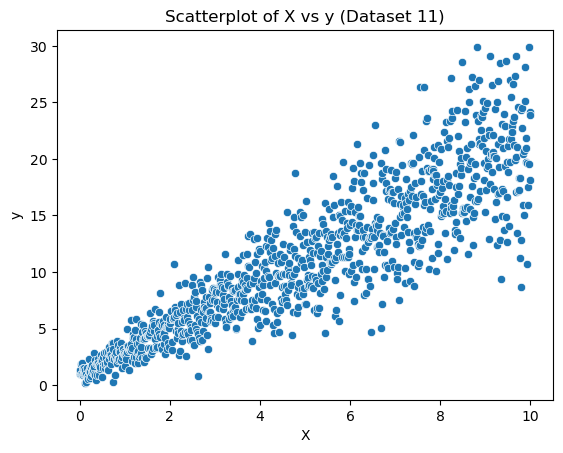

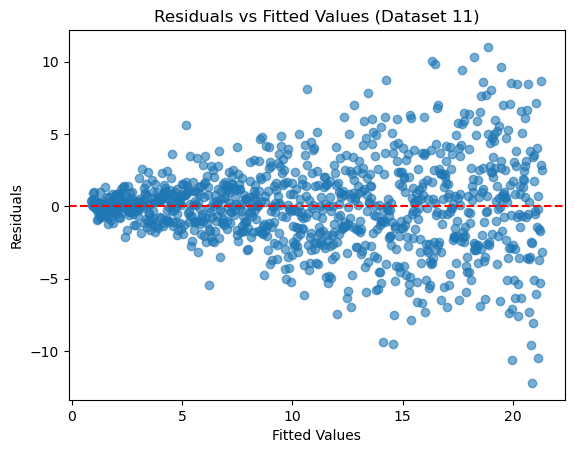

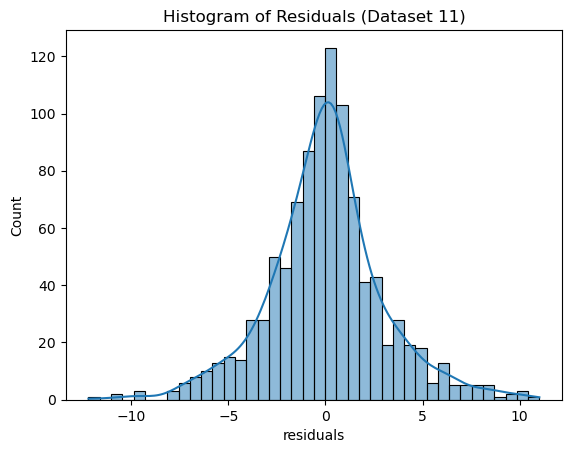

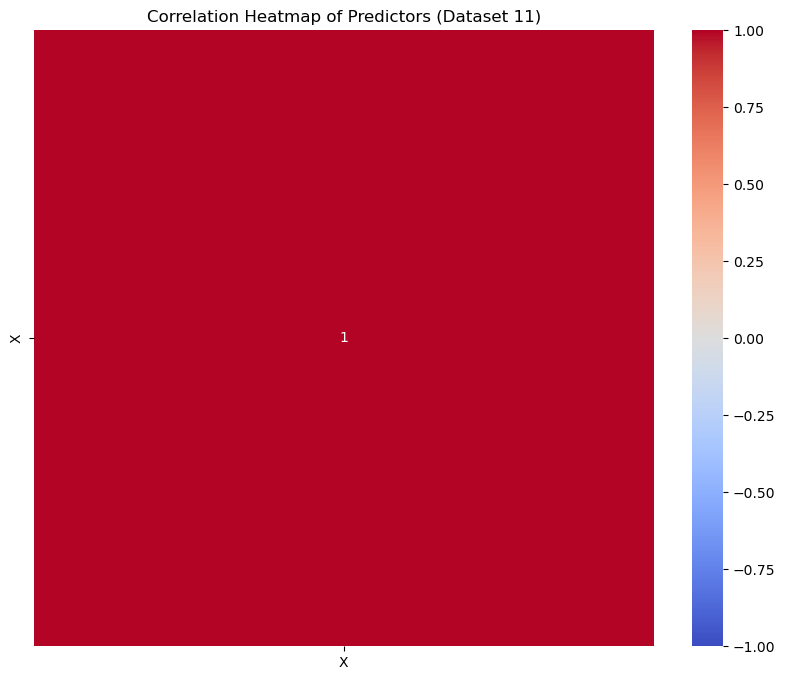

Intercept: 0.869
Coefficient for X: 2.046
Durbin-Watson: 1.98

Variance Inflation Factors (VIF):
  Feature       VIF
0   const  3.994006
1       X  1.000000


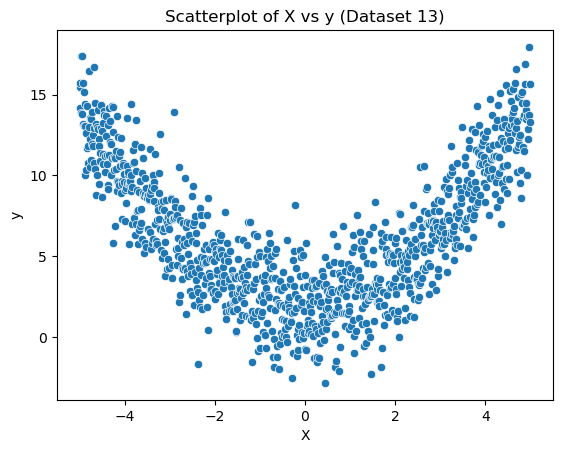

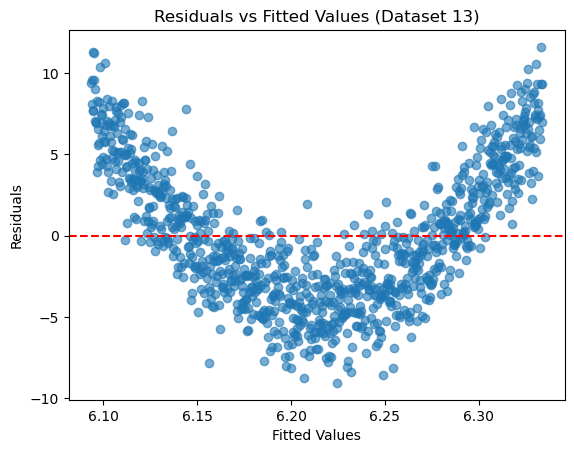

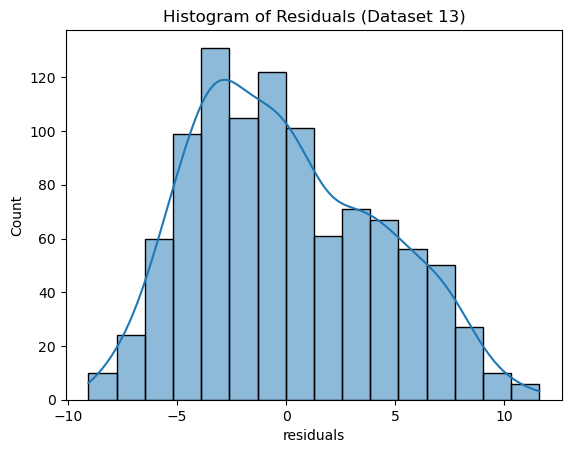

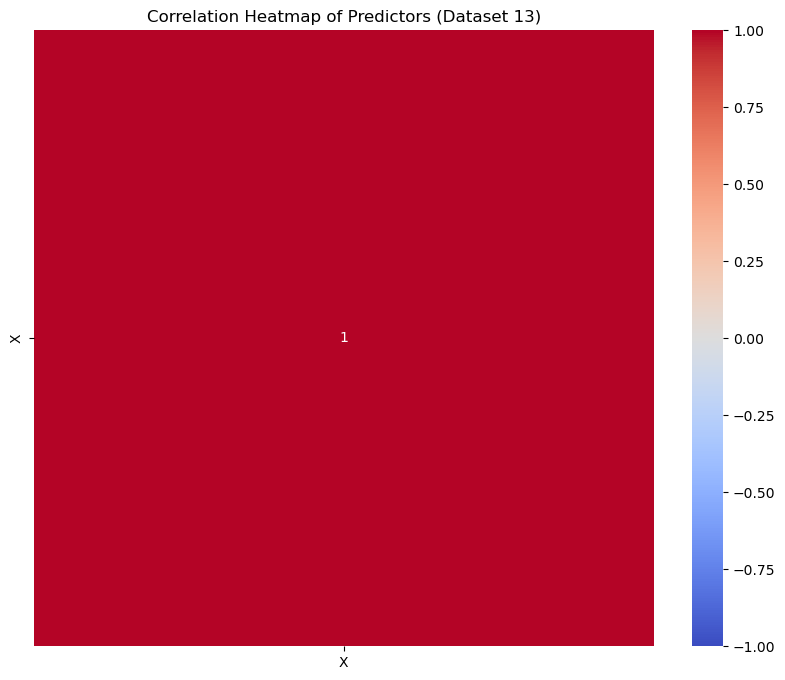

Intercept: 6.214
Coefficient for X: 0.024
Durbin-Watson: 0.431

Variance Inflation Factors (VIF):
  Feature  VIF
0   const  1.0
1       X  1.0


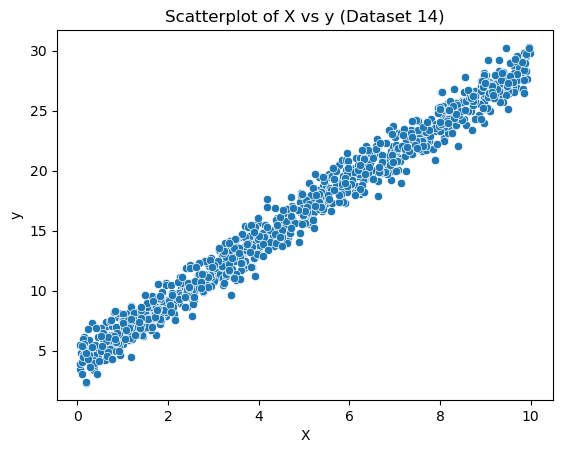

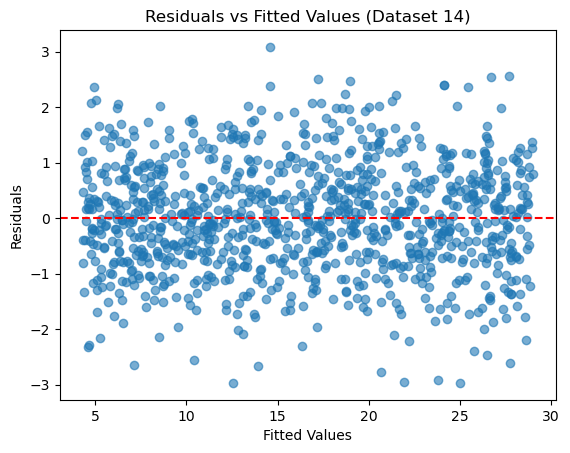

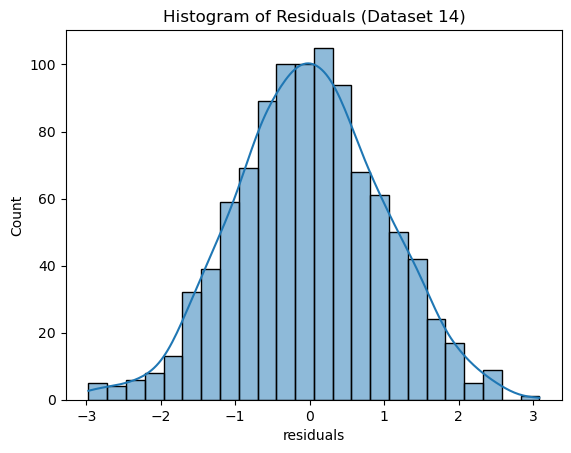

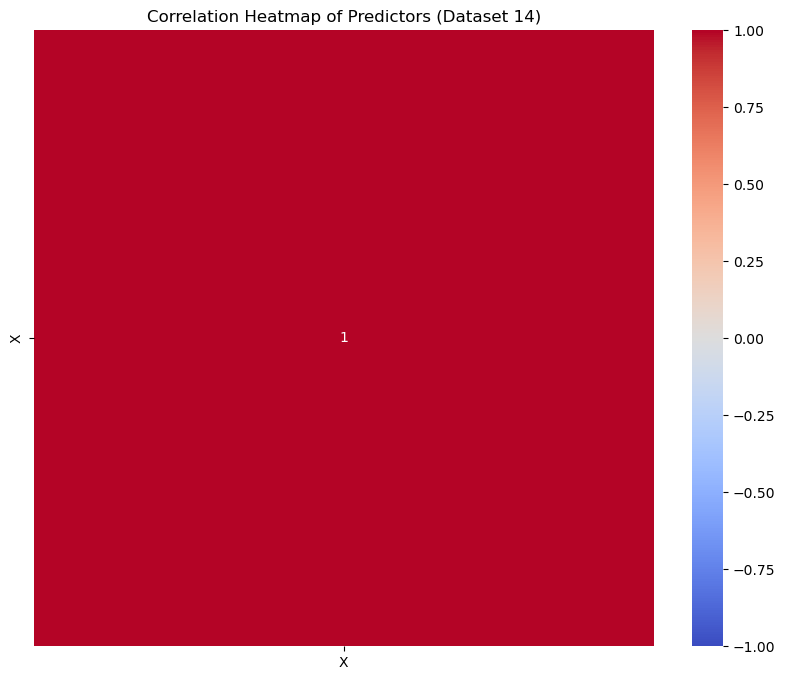

Intercept: 4.175
Coefficient for X: 2.485
Durbin-Watson: 2.002

Variance Inflation Factors (VIF):
  Feature       VIF
0   const  3.819078
1       X  1.000000


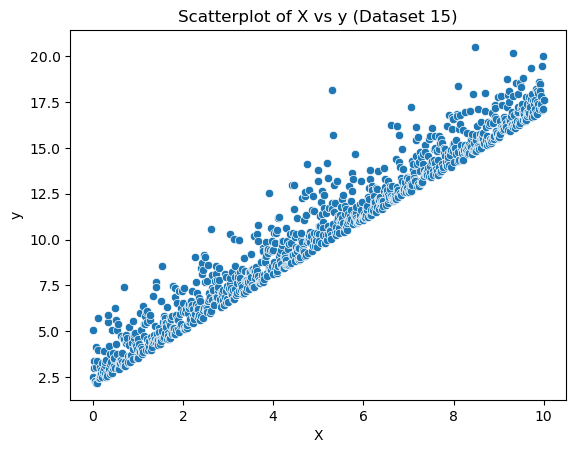

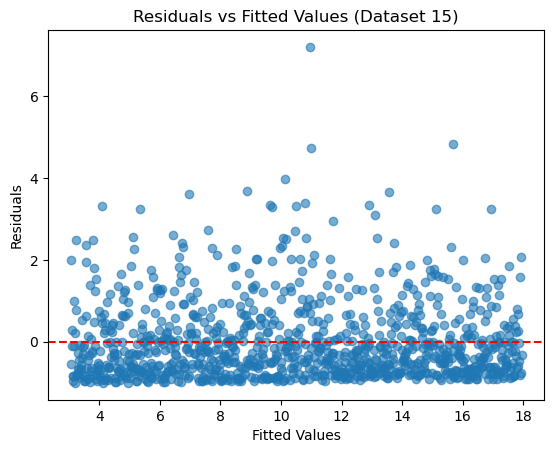

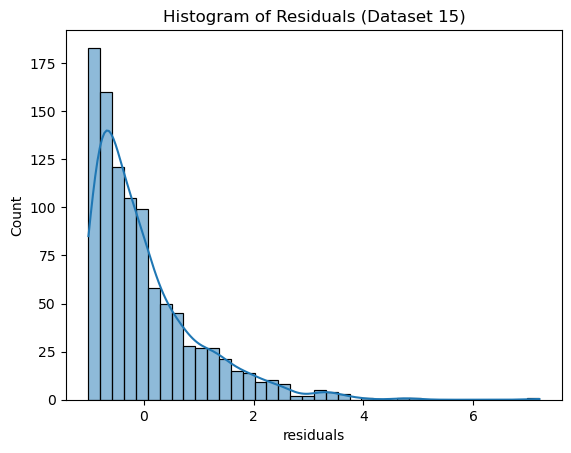

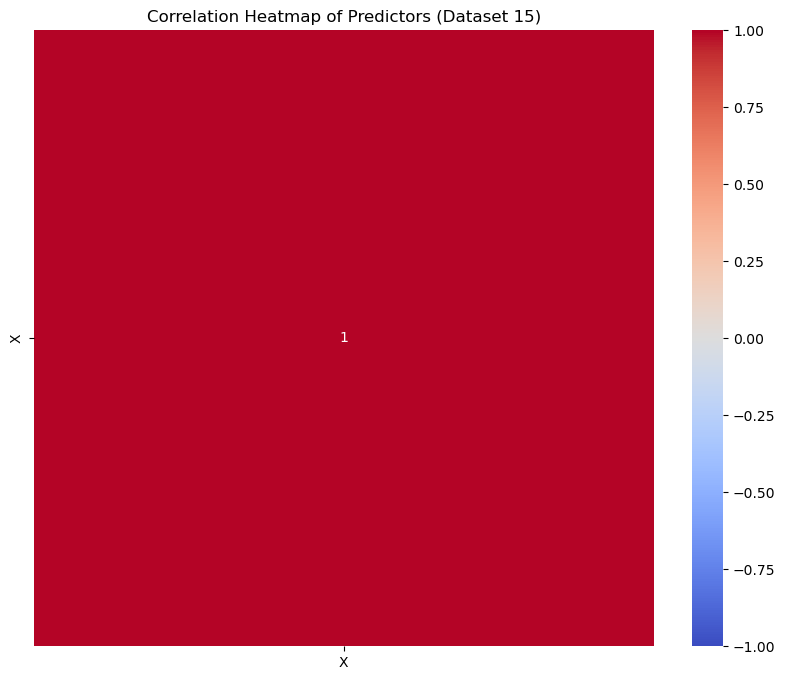

Intercept: 3.05
Coefficient for X: 1.49
Durbin-Watson: 1.869

Variance Inflation Factors (VIF):
  Feature       VIF
0   const  3.994006
1       X  1.000000


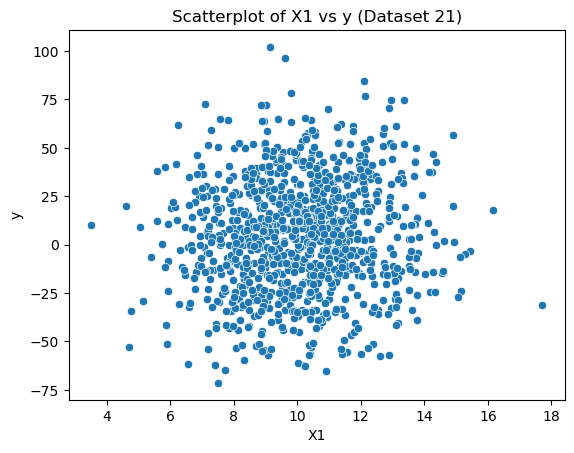

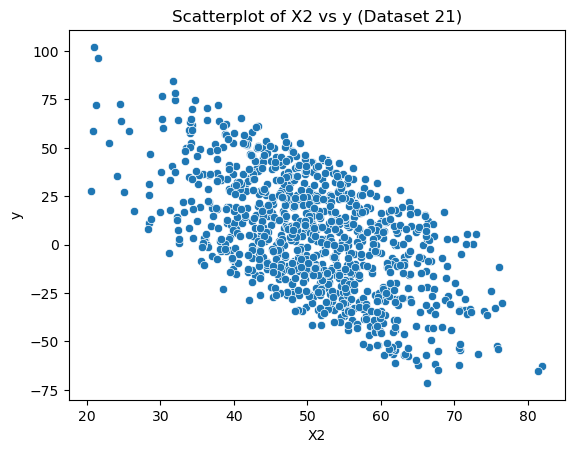

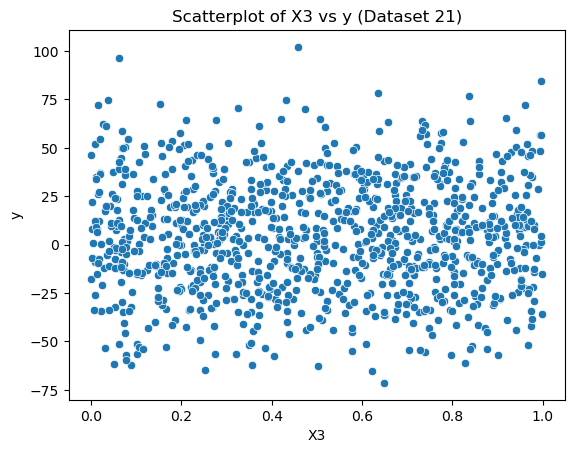

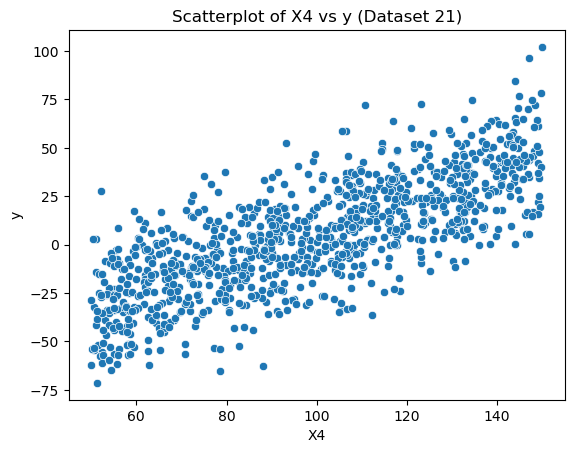

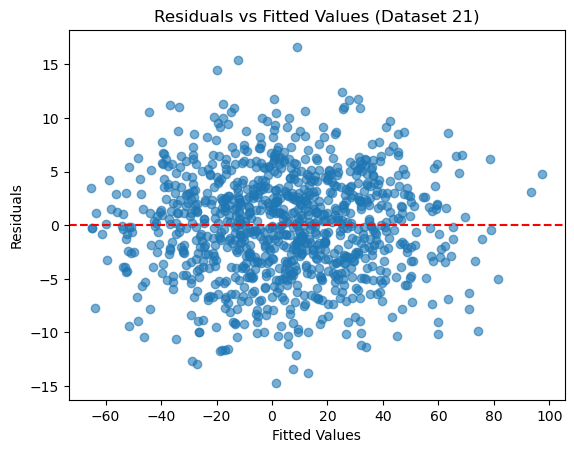

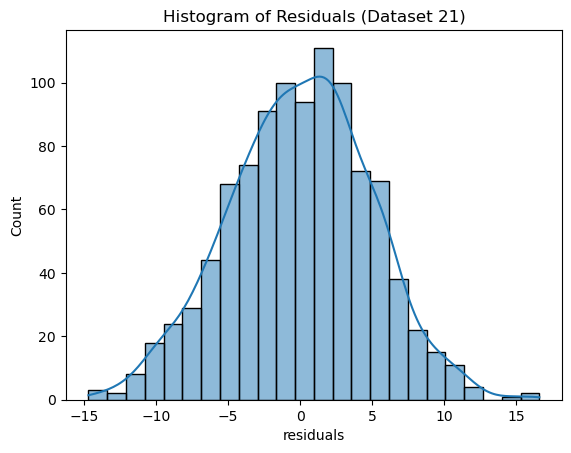

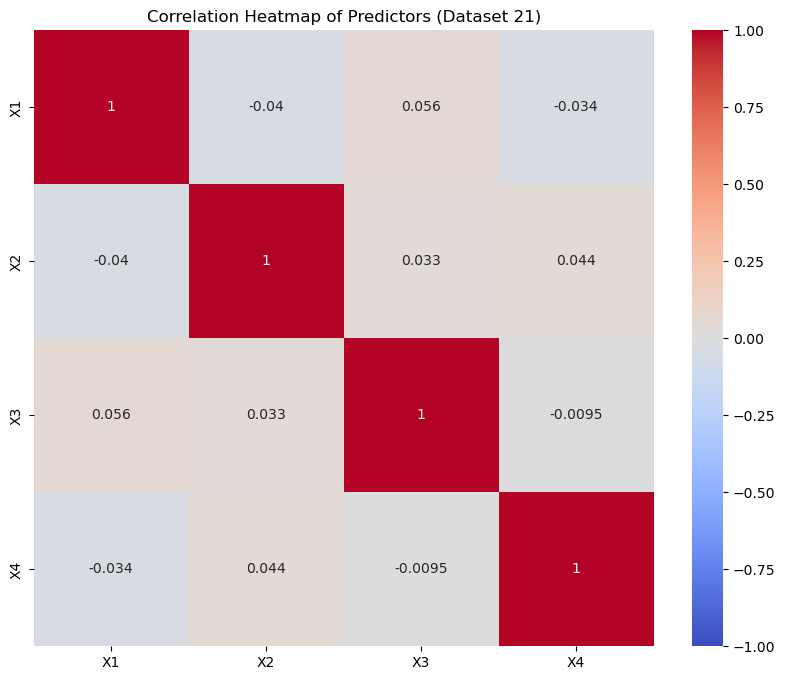

Intercept: 2.82
Coefficient for X1: 1.135
Coefficient for X2: -1.785
Coefficient for X3: 3.249
Coefficient for X4: 0.802
Durbin-Watson: 2.011

Variance Inflation Factors (VIF):
  Feature        VIF
0   const  68.759277
1      X1   1.005927
2      X2   1.004735
3      X3   1.004440
4      X4   1.003075


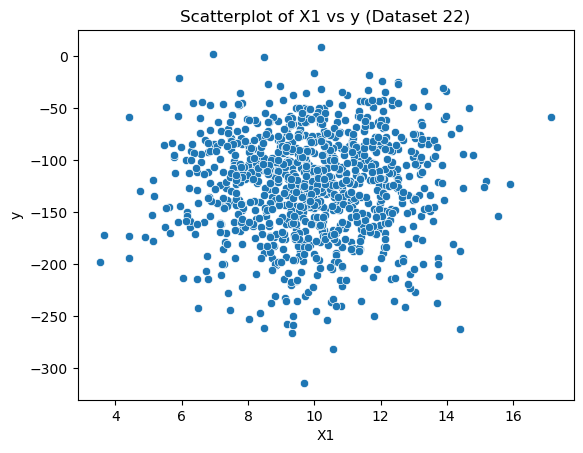

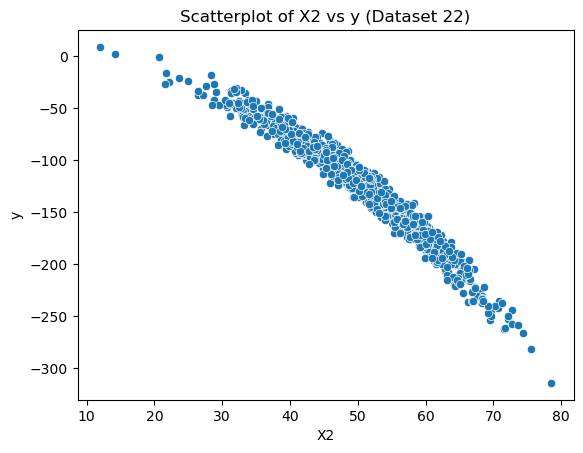

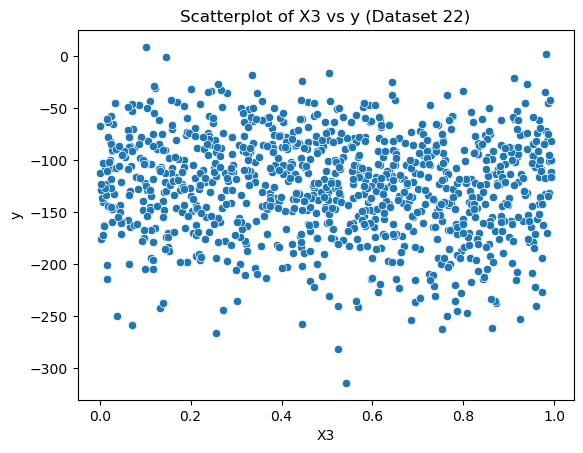

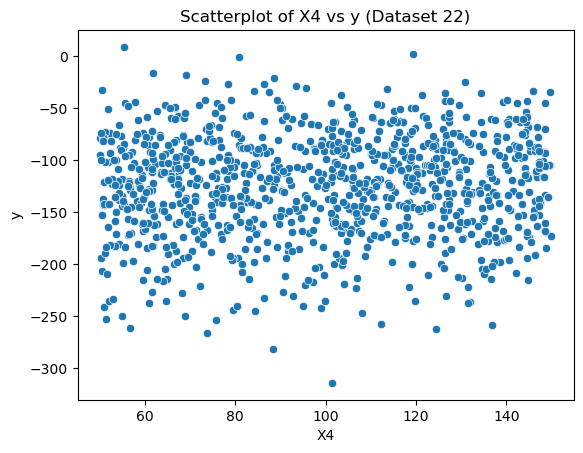

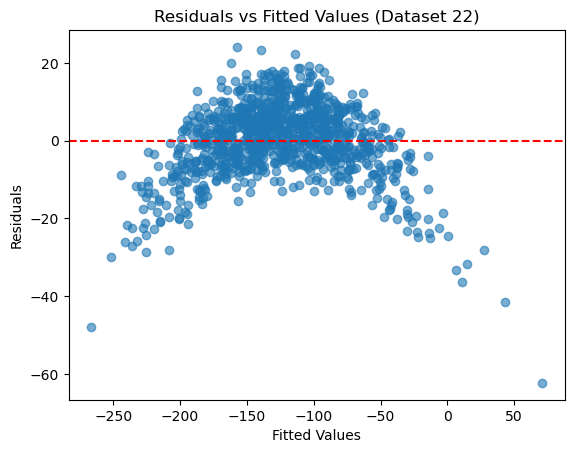

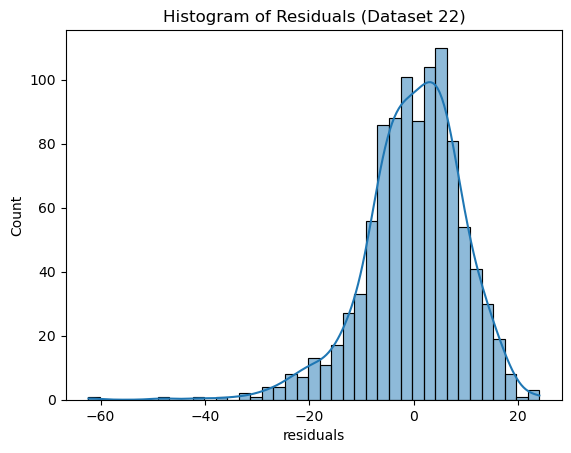

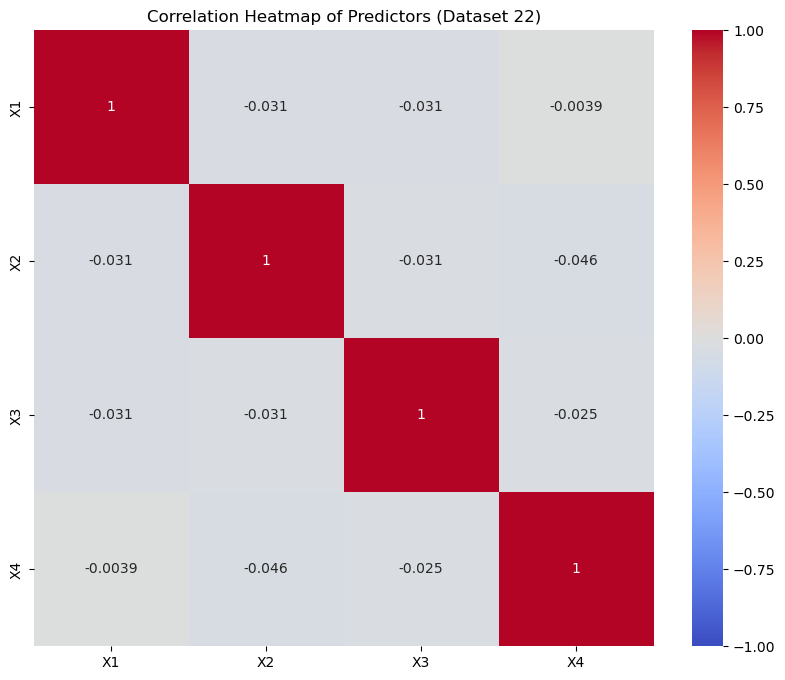

Intercept: 130.433
Coefficient for X1: 0.075
Coefficient for X2: -4.95
Coefficient for X3: -20.356
Coefficient for X4: 0.019
Durbin-Watson: 2.133

Variance Inflation Factors (VIF):
  Feature        VIF
0   const  72.776539
1      X1   1.002065
2      X2   1.004274
3      X3   1.002735
4      X4   1.002910


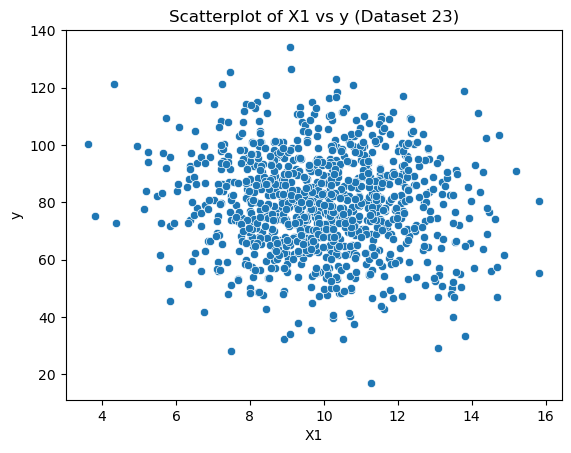

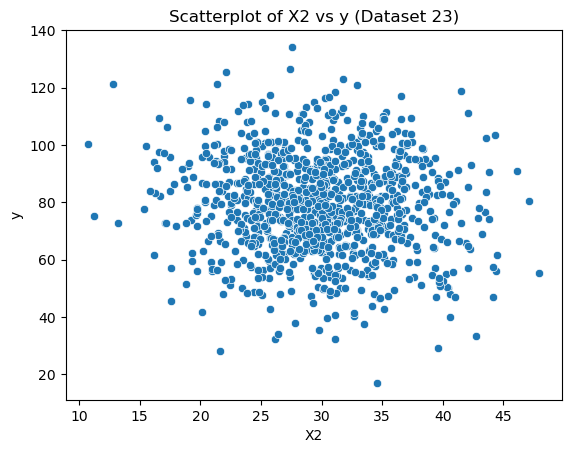

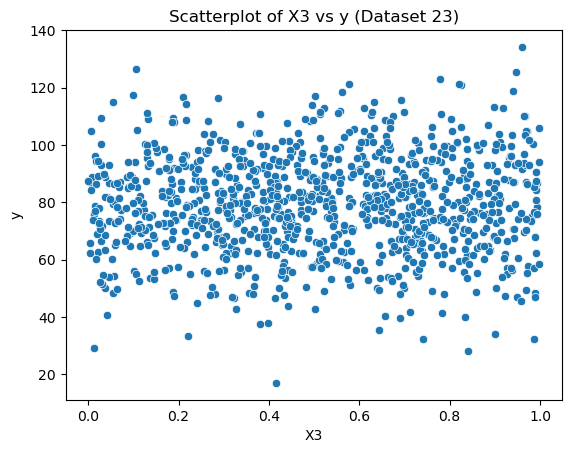

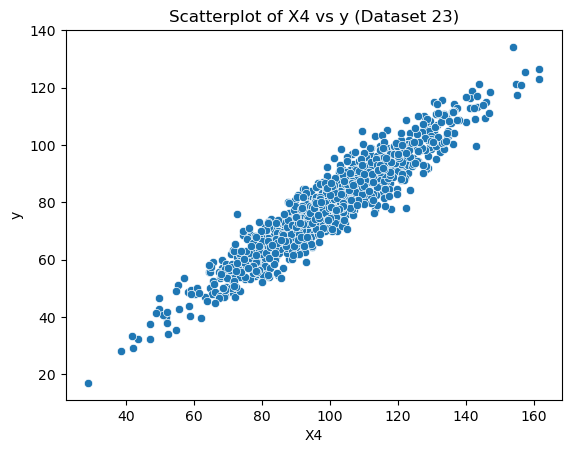

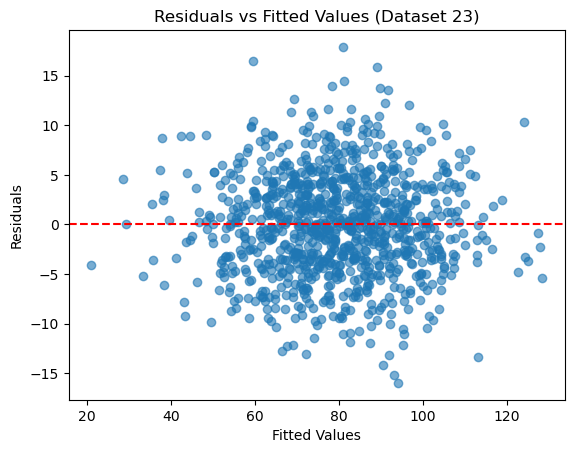

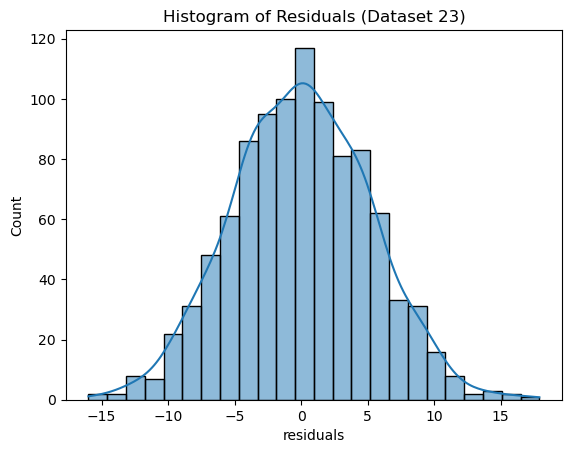

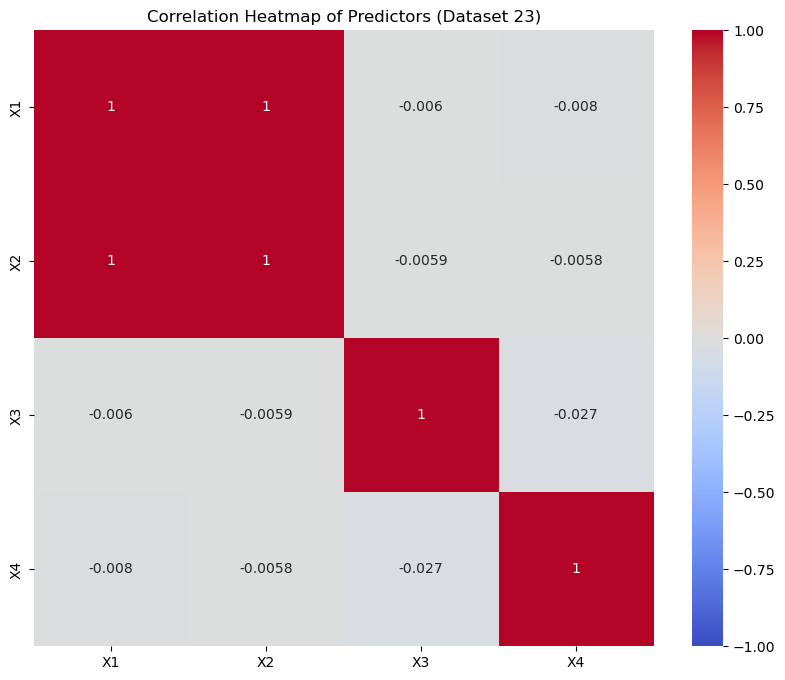

Intercept: 4.034
Coefficient for X1: 0.996
Coefficient for X2: -0.54
Coefficient for X3: 3.206
Coefficient for X4: 0.796
Durbin-Watson: 1.982

Variance Inflation Factors (VIF):
  Feature         VIF
0   const   56.648174
1      X1  128.794329
2      X2  128.790165
3      X3    1.000759
4      X4    1.001425


FileNotFoundError: [Errno 2] No such file or directory: 'APMM8-assignment2-dataset24.csv'

In [116]:
results_list = []

for x in featlist:
    results = cesar(f"APMM8-assignment2-dataset{x}.csv", x)
    results_list.append(results)

In [117]:
results_df = pd.DataFrame(results_list)

In [143]:
results_df.loc[results_df.dataset == 10]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
0,APMM8-assignment2-dataset10.csv,10,1.798,{'X': 3.059},0.41,Feature VIF 0 const 3.994006 1 X 1.000000,X X 1.0,"0 0.698848 1 0.460647 2 1.055919 3 2.407360 4 1.731211 ... 995 -2.718653 996 -0.455659 997 0.197775 998 -0.491619 999 0.100508 Name: residuals, Length: 1000, dtype: float64","0 1.797866 1 1.828490 2 1.859115 3 1.889739 4 1.920363 ... 995 32.269021 996 32.299645 997 32.330270 998 32.360894 999 32.391518 Name: y_pred, Length: 1000, dtype: float64"


In [142]:
results_df.loc[results_df.dataset == 11]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
1,APMM8-assignment2-dataset11.csv,11,0.869,{'X': 2.046},1.98,Feature VIF 0 const 3.994006 1 X 1.000000,X X 1.0,"0 0.379372 1 0.060801 2 0.459776 3 0.911734 4 0.007883 ... 995 -1.726260 996 8.637857 997 2.871699 998 -3.180523 999 2.535254 Name: residuals, Length: 1000, dtype: float64","0 0.868985 1 0.889464 2 0.909943 3 0.930422 4 0.950901 ... 995 21.245743 996 21.266223 997 21.286702 998 21.307181 999 21.327660 Name: y_pred, Length: 1000, dtype: float64"


In [144]:
results_df.loc[results_df.dataset == 13]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
2,APMM8-assignment2-dataset13.csv,13,6.214,{'X': 0.024},0.431,Feature VIF 0 const 1.0 1 X 1.0,X X 1.0,"0 9.399940 1 8.079742 2 9.601508 3 11.302150 4 7.737844 ... 995 7.405507 996 11.612539 997 9.348411 998 6.974026 999 9.311309 Name: residuals, Length: 1000, dtype: float64","0 6.093488 1 6.093729 2 6.093970 3 6.094210 4 6.094451 ... 995 6.332894 996 6.333135 997 6.333375 998 6.333616 999 6.333856 Name: y_pred, Length: 1000, dtype: float64"


In [145]:
results_df.loc[results_df.dataset == 14]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
3,APMM8-assignment2-dataset14.csv,14,4.175,{'X': 2.485},2.002,Feature VIF 0 const 3.819078 1 X 1.000000,X X 1.0,"0 0.060894 1 -1.362968 2 0.318719 3 0.528469 4 0.409160 ... 995 -1.480627 996 -0.644563 997 -0.190640 998 -0.457000 999 -0.798166 Name: residuals, Length: 1000, dtype: float64","0 13.480310 1 27.795481 2 22.361327 3 19.048579 4 8.051097 ... 995 6.450157 996 26.965633 997 7.574069 998 27.783631 999 15.255890 Name: y_pred, Length: 1000, dtype: float64"


In [146]:
results_df.loc[results_df.dataset == 15]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
4,APMM8-assignment2-dataset15.csv,15,3.05,{'X': 1.49},1.869,Feature VIF 0 const 3.994006 1 X 1.000000,X X 1.0,"0 -0.553011 1 1.987942 2 0.294666 3 -0.109038 4 -0.852256 ... 995 -0.827081 996 1.569668 997 -0.775802 998 2.077658 999 -0.332132 Name: residuals, Length: 1000, dtype: float64","0 3.049773 1 3.064688 2 3.079604 3 3.094519 4 3.109435 ... 995 17.890565 996 17.905481 997 17.920396 998 17.935312 999 17.950227 Name: y_pred, Length: 1000, dtype: float64"


In [148]:
results_df.loc[results_df.dataset == 21]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
5,APMM8-assignment2-dataset21.csv,21,2.82,"{'X1': 1.135, 'X2': -1.785, 'X3': 3.249, 'X4': 0.802}",2.011,Feature VIF 0 const 68.759277 1 X1 1.005927 2 X2 1.004735 3 X3 1.004440 4 X4 1.003075,X1 X2 X3 X4 X1 1.000000 -0.040400 0.055580 -0.034252 X2 -0.040400 1.000000 0.033051 0.043879 X3 0.055580 0.033051 1.000000 -0.009530 X4 -0.034252 0.043879 -0.009530 1.000000,"0 5.451692 1 2.822115 2 11.727332 3 -7.041149 4 6.674103 ... 995 5.978303 996 5.930437 997 4.798076 998 -2.289999 999 -4.952180 Name: residuals, Length: 1000, dtype: float64","0 -33.284092 1 -6.440043 2 30.971641 3 -8.640067 4 1.180943 ... 995 -30.916751 996 4.452633 997 47.777256 998 -32.003990 999 33.223872 Name: y_pred, Length: 1000, dtype: float64"


In [140]:
results_df.loc[results_df.dataset == 22]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
6,APMM8-assignment2-dataset22.csv,22,130.433,"{'X1': 0.075, 'X2': -4.95, 'X3': -20.356, 'X4': 0.019}",2.133,Feature VIF 0 const 72.776539 1 X1 1.002065 2 X2 1.004274 3 X3 1.002735 4 X4 1.002910,X1 X2 X3 X4 X1 1.000000 -0.031283 -0.031317 -0.003854 X2 -0.031283 1.000000 -0.031112 -0.046443 X3 -0.031317 -0.031112 1.000000 -0.025115 X4 -0.003854 -0.046443 -0.025115 1.000000,"0 0.145226 1 2.449895 2 -4.222913 3 -4.187646 4 8.871899 ... 995 4.754598 996 -2.232564 997 5.828844 998 -11.748594 999 14.711090 Name: residuals, Length: 1000, dtype: float64","0 -84.976755 1 -149.681543 2 -164.698916 3 -80.222724 4 -146.449583 ... 995 -158.447121 996 -65.871377 997 -104.228372 998 -49.974887 999 -121.418638 Name: y_pred, Length: 1000, dtype: float64"


In [141]:
results_df.loc[results_df.dataset == 23]

,data,dataset,intercept,coefficients,durbin_watson,vif,correlation_matrix,residuals,predictions
7,APMM8-assignment2-dataset23.csv,23,4.034,"{'X1': 0.996, 'X2': -0.54, 'X3': 3.206, 'X4': 0.796}",1.982,Feature VIF 0 const 56.648174 1 X1 128.794329 2 X2 128.790165 3 X3 1.000759 4 X4 1.001425,X1 X2 X3 X4 X1 1.000000 0.996108 -0.005984 -0.008017 X2 0.996108 1.000000 -0.005943 -0.005762 X3 -0.005984 -0.005943 1.000000 -0.026823 X4 -0.008017 -0.005762 -0.026823 1.000000,"0 6.388117 1 -4.693613 2 -9.222198 3 4.660568 4 -5.181883 ... 995 -2.233286 996 2.165384 997 1.596109 998 -1.811744 999 -0.663582 Name: residuals, Length: 1000, dtype: float64","0 80.621192 1 86.884316 2 78.547827 3 84.523677 4 74.259247 ... 995 127.832573 996 78.076449 997 71.156405 998 43.600975 999 76.299514 Name: y_pred, Length: 1000, dtype: float64"
